<a href="https://colab.research.google.com/github/waweru-ke/NLP-Sentiment-Analysis-Based-Trading-Strategies/blob/main/NLP_and_Sentiment_Analysis%E2%80%93Based_Trading_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

The problem statement is to build a trading strategy that uses NLP to extracts the information inside the news headlines, assigns a sentiment to that and use the sentiments and the information inside the news headlines for a trading strategy.

The data used for this case study will be from three sources:

* News headlines data compiled from RSS feeds of several news websites: This news headlines data is complied by different news website and contains the most financially relevant news filtered by human editors. For the purpose of this study, we will only look at the headline, not the details in the story. Another important characteristic of this dataset is that the relevant tickers in the story are extracted. Our dataset contains 82,643 headlines from to 2011-05-02 to 2018-12-28

* Yahoo finance website for the stock return: (The return data can be obtained from other website such as yahoo finance)a
kaggle: labelled data of of news sentiments obtained for a classification based sentiment analysis model. This data may not be authentic and is used only for demonstration purpose in this case study.

* Stock market lexicon created based on stock market conversations in microblogging services. The source of this lexicon is Oliveira, Nuno, Paulo Cortez, and Nelson Areal. "Stock market sentiment lexicon acquisition using microblogging data and statistical measures." Decision Support Systems 85 (2016): 62-73.

In [11]:
import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set}
required = {'nltk', 'spacy', 'textblob', 'backtrader', 'curl-cffi'}
missing = required - installedPackages
if missing:
    !pip install -U nltk textblob
    !pip install -U spacy
    !python -m spacy download en_core_web_lg
    !pip install -U curl-cffi
    !pip install backtrader==1.9.74.123

In [3]:
#NLP libraries
from textblob import TextBlob
import spacy
import nltk
import warnings
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Configure NLTK to bypass the security block over the proxy
nltk.pathsec.ALLOW_PROXIED_FETCH = True
nltk.download('vader_lexicon')
import csv
import pandas as pd

#Run the command python -m spacy download en_core_web_sm to download this
#https://spacy.io/models
import en_core_web_lg
nlp = en_core_web_lg.load()

#Libraries for processing the news headlines
from lxml import etree
import json
from io import StringIO
from os import listdir
from os.path import isfile, join
from pandas.tseries.offsets import BDay
from scipy.stats.mstats import winsorize
from copy import copy

# Libraries for Classification for modeling the sentiments
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras package for the deep learning model for the sentiment prediction.
# Importing from tensorflow.keras avoids path issues in modern Keras 3.x
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, Dropout, Activation, Embedding

# Load libraries
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf

#Additional Libraries
import json
import zipfile
import os.path
import sys

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [4]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

## Data Preparation

In [67]:
df_ticker_return = pd.read_csv("/content/Step2.2_ReturnData.csv")

In [68]:
df_ticker_return.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
0,2010-01-04,26.40,26.53,26.27,26.47,123432400,0.0,0.0,AAPL
1,2010-01-05,26.54,26.66,26.37,26.51,150476200,0.0,0.0,AAPL
2,2010-01-06,26.51,26.62,26.06,26.09,138040000,0.0,0.0,AAPL
3,2010-01-07,26.19,26.22,25.85,26.04,119282800,0.0,0.0,AAPL
4,2010-01-08,26.01,26.22,25.85,26.22,111902700,0.0,0.0,AAPL


In [24]:
z = zipfile.ZipFile("/content/Raw Headline Data.zip", "r")

In [31]:
testFile = z.namelist()[:10]
testFile

['Raw Headline Data/2011-05-01.json',
 'Raw Headline Data/2011-05-02.json',
 'Raw Headline Data/2011-05-03.json',
 'Raw Headline Data/2011-05-04.json',
 'Raw Headline Data/2011-05-05.json',
 'Raw Headline Data/2011-05-06.json',
 'Raw Headline Data/2011-05-07.json',
 'Raw Headline Data/2011-05-08.json',
 'Raw Headline Data/2011-05-09.json',
 'Raw Headline Data/2011-05-10.json']

In [39]:
fileData = z.open(testFile[-1]).read()
fileData[:1000]

b'{"content":"<li class=\\"n-box-item date-title\\" data-end=\\"1305086399\\" data-start=\\"1305000000\\" data-txt=\\"Tuesday, December 17, 2019\\">Tuesday, May 10, 2011</li><li class=\\"n-box-item sa-box-item\\" data-id=\\"76058\\" data-ts=\\"1305060851\\"><div class=\\"media media-overflow-fix\\"><div class=\\"media-left\\"><a class=\\"box-ticker\\" href=\\"/symbol/MCPIQ\\" target=\\"_blank\\">MCPIQ</a></div><div class=\\"media-body\\"><h4 class=\\"media-heading\\"><a href=\\"/news/76058\\" sasource=\\"on_the_move_news_fidelity\\" target=\\"_blank\\">Molycorp (MCP) shares -6.0% AH after missing earnings on both the top and bottom lines. The fall...</a></h4> Molycorp (MCP) shares <font color=\\"red\\">-6.0%</font> AH after <a target=\\"_blank\\" href=\\"https://seekingalpha.com/currents/post/76043\\">missing earnings</a> on both the top and bottom lines. The fall comes on top of a 7.2% plunge in the regular session, bringing the day\'s total drop to a silver-like 12.6%. Still, the dec

In [42]:
sample = json.loads(fileData)

In [43]:
sample.keys()

dict_keys(['content', 'count', 'message', 'success', 'today', 'yesterday'])

In [45]:
sample1 = sample['content'][:1500]
sample1

'<li class="n-box-item date-title" data-end="1305086399" data-start="1305000000" data-txt="Tuesday, December 17, 2019">Tuesday, May 10, 2011</li><li class="n-box-item sa-box-item" data-id="76058" data-ts="1305060851"><div class="media media-overflow-fix"><div class="media-left"><a class="box-ticker" href="/symbol/MCPIQ" target="_blank">MCPIQ</a></div><div class="media-body"><h4 class="media-heading"><a href="/news/76058" sasource="on_the_move_news_fidelity" target="_blank">Molycorp (MCP) shares -6.0% AH after missing earnings on both the top and bottom lines. The fall...</a></h4> Molycorp (MCP) shares <font color="red">-6.0%</font> AH after <a target="_blank" href="https://seekingalpha.com/currents/post/76043">missing earnings</a> on both the top and bottom lines. The fall comes on top of a 7.2% plunge in the regular session, bringing the day\'s total drop to a silver-like 12.6%. Still, the decline barely registers on a <a target="_blank" href="http://www.google.com//finance?chdnp=1&am

In [46]:
# This function performs the json parsing given the
def jsonParser(json_data):
    xml_data = json_data['content']

    tree = etree.parse(StringIO(xml_data), parser=etree.HTMLParser())

    headlines = tree.xpath("//h4[contains(@class, 'media-heading')]/a/text()")
    assert len(headlines) == json_data['count']

    main_tickers = list(map(lambda x: x.replace('/symbol/', ''), tree.xpath("//div[contains(@class, 'media-left')]//a/@href")))
    assert len(main_tickers) == json_data['count']
    final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]/ul/li[1]")]
    if len(final_headlines) == 0:
        final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]")]
        final_headlines = [f.replace(h, '').split('\xa0')[0].strip() for f,h in zip (final_headlines, headlines)]
    return main_tickers, final_headlines

In [55]:
jsonParser(json.loads(fileData))[1][1]

'"There\'s not a single change in any of the plans," outgoing Boston Scientific (BSX -8.2%) CEO Ray Elliott said at today\'s shareholder meeting, after announcing his surprise exit. BSX shares had fallen about 20% since Elliott took the reins, but Wall Street has credited him for steady-footing BSX, and looked to him to improve profitability.'

In [62]:
data = None
data_df_news = []
ret = []
ret_f = []
with zipfile.ZipFile("Raw Headline Data.zip", "r") as z:
    for filename in z.namelist():
        #print(filename)
        try:
            #print('Running {}'.format(filename))
            with z.open(filename) as f:
                data = f.read()
                json_data = json.loads(data)
            if json_data.get('count', 0)> 10:
                #Step 1: Parse the News Jsons
                main_tickers, final_headlines = jsonParser(json_data)
                if len(final_headlines) != json_data['count']:
                    continue
                #Step 2: Prepare Future and Event Return and assign Future and Event return for each ticker.
                file_date = filename.split('/')[-1].replace('.json', '')
                file_date = date(int(file_date[:4]), int(file_date[5:7]), int(file_date[8:]))
               #Step 3: Merge all the data in a data frame
                df_dict = {'ticker': main_tickers,
                           'headline': final_headlines,
                           'date': [file_date] * len(main_tickers)
                           }
                df_f = pd.DataFrame(df_dict)
                data_df_news.append(df_f)
        except:
            pass

In [63]:
data_df_news=pd.concat(data_df_news)
data_df_news.head()

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02
2,AEIS,Advanced Energy Industries (NASDAQ:AEIS):,2011-05-02
3,LOCM,Local.com (NASDAQ:LOCM):,2011-05-02
4,CYDEQ,CyberDefender (CYDE):,2011-05-02


In [69]:
#Computing the return
df_ticker_return['ret_curr'] = df_ticker_return['Close'].pct_change()
#Computing the event return
df_ticker_return['eventRet'] = df_ticker_return['ret_curr'] + df_ticker_return['ret_curr'].shift(-1) + df_ticker_return['ret_curr'].shift(1)
df_ticker_return.reset_index(level=0, inplace=True)
df_ticker_return['date'] = pd.to_datetime(df_ticker_return['Date']).apply(lambda x: x.date())

In [70]:
df_ticker_return.head()

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,ret_curr,eventRet,date
0,0,2010-01-04,26.40,26.53,26.27,26.47,123432400,0.0,0.0,AAPL,NaN,NaN,2010-01-04
1,1,2010-01-05,26.54,26.66,26.37,26.51,150476200,0.0,0.0,AAPL,0.001511,NaN,2010-01-05
2,2,2010-01-06,26.51,26.62,26.06,26.09,138040000,0.0,0.0,AAPL,-0.015843,-0.016248,2010-01-06
3,3,2010-01-07,26.19,26.22,25.85,26.04,119282800,0.0,0.0,AAPL,-0.001916,-0.010847,2010-01-07
4,4,2010-01-08,26.01,26.22,25.85,26.22,111902700,0.0,0.0,AAPL,0.006912,-0.004157,2010-01-08


In [71]:
tickers = ['AAPL','MSFT','AMZN','GOOG','FB','WMT','JPM','TSLA','NFLX','ADBE']
start = '2010-01-01'
end = '2018-12-31'

In [72]:
combinedDataFrame = pd.merge(data_df_news, df_ticker_return, how='left', left_on=['date','ticker'], right_on=['date','ticker'])
combinedDataFrame = combinedDataFrame[combinedDataFrame['ticker'].isin(tickers)]
data_df = combinedDataFrame[['ticker','headline','date','eventRet','Close']]
data_df = data_df.dropna()

In [73]:
data_df.head()

,ticker,headline,date,eventRet,Close
5,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.017650,201.19
11,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,-0.013003,33.88
74,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.019823,20.63
77,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.019823,20.63
86,MSFT,,2011-05-10,-0.019823,20.63


## Evaluate Models for Sentiment Analysis

### Predefined model-TextBlob package

In [74]:
text1 = "Bayer (OTCPK:BAYRY) started the week up 3.5% to €74/share in Frankfurt, touching their \
highest level in 14 months, after the U.S. government said a $25M glyphosate decision against the \
company should be reversed."

In [76]:
TextBlob(text1).sentiment.polarity

0.5

The sentiment polarity is a number between -1 (Very Negative) and +1 (Very Positive). We apply this on all headline we have in the data processed in the previous step. Let us compute the sentiment for all the headlines in the data

In [77]:
data_df['sentiment_textblob'] = [TextBlob(s).sentiment.polarity for s in data_df['headline']]

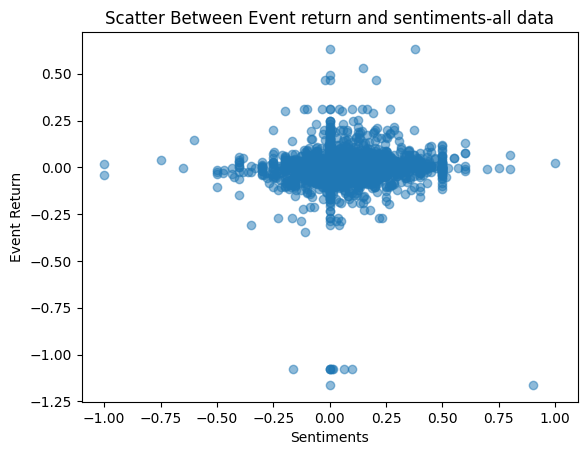

In [79]:
#Checking correlation btwn sentiment and return
plt.scatter(data_df['sentiment_textblob'],data_df['eventRet'], alpha=0.5)
plt.title('Scatter Between Event return and sentiments-all data')
plt.ylabel('Event Return')
plt.xlabel('Sentiments')
plt.show()

In [82]:
corrlation = data_df['eventRet'].corr(data_df['sentiment_textblob'])
print(corrlation)

0.042572337384901154


The correlation is +ve. Implication is that positive sentiment leads to higher return

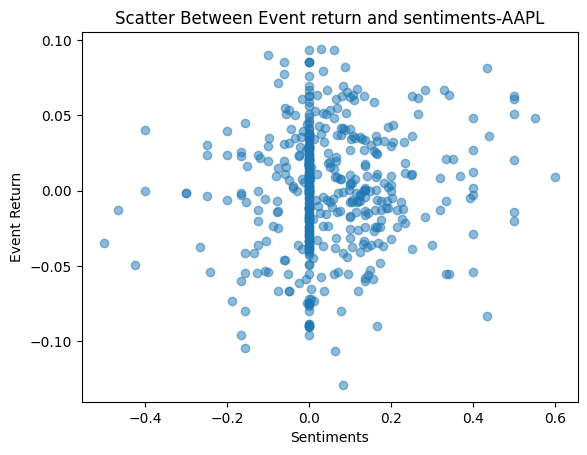

In [83]:
data_df_stock  = data_df[data_df['ticker'] == 'AAPL']
plt.scatter(data_df_stock['sentiment_textblob'],data_df_stock['eventRet'], alpha=0.5)
plt.title('Scatter Between Event return and sentiments-AAPL')
plt.ylabel('Event Return')
plt.xlabel('Sentiments')
plt.show()

A lot of the sentiments seem to lie at zero.


## Supervised Learning-Classification algorithms and LSTM

In [85]:
sentiments_data = pd.read_csv(r'LabelledNewsData.csv',encoding = "ISO-8859-1")

In [86]:
sentiments_data.head()

,datetime,headline,ticker,sentiment
0,1/16/2020 5:25,$MMM fell on hard times but could be set to re...,MMM,0
1,1/11/2020 6:43,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,MMM,1
2,1/9/2020 9:37,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,MMM,1
3,1/8/2020 17:01,$MMM #insideday follow up as it also opened up...,MMM,1
4,1/8/2020 7:44,$MMM is best #dividend #stock out there and do...,MMM,0


In [88]:
#word-embedding
all_vectors = np.array([np.array([token.vector for token in nlp(s) ]).mean(axis=0)*np.ones((300)) \
                           for s in sentiments_data['headline']])

In [89]:
# split out validation dataset for the end
Y= sentiments_data["sentiment"]
X = all_vectors

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
validation_size = 0.3
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=validation_size, random_state=seed)

# test options for classification
num_folds = 10
seed = 7
scoring = 'accuracy'

# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
#Neural Network
models.append(('NN', MLPClassifier()))
#Ensable Models
models.append(('RF', RandomForestClassifier()))

In [91]:
results = []
names = []
kfold_results = []
test_results = []
train_results = []
for name, model in models:
    kfold = KFold(n_splits=num_folds)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    #msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    #print(msg)
   # Full Training period
    res = model.fit(X_train, Y_train)
    train_result = accuracy_score(res.predict(X_train), Y_train)
    train_results.append(train_result)

    # Test results
    test_result = accuracy_score(res.predict(X_test), Y_test)
    test_results.append(test_result)

    msg = "%s: %f (%f) %f %f" % (name, cv_results.mean(), cv_results.std(), train_result, test_result)
    print(msg)
    print(confusion_matrix(res.predict(X_test), Y_test))

LR: 0.880676 (0.009577) 0.896063 0.875748
[[1047  166]
 [ 187 1441]]
KNN: 0.785942 (0.025526) 0.869060 0.787751
[[ 932  301]
 [ 302 1306]]
CART: 0.687283 (0.023650) 0.999698 0.677578
[[ 761  443]
 [ 473 1164]]
SVM: 0.895004 (0.011712) 0.919897 0.896515
[[1087  147]
 [ 147 1460]]
NN: 0.923367 (0.008893) 0.999698 0.935938
[[1154  102]
 [  80 1505]]
RF: 0.814300 (0.016955) 0.999698 0.824006
[[ 873  139]
 [ 361 1468]]


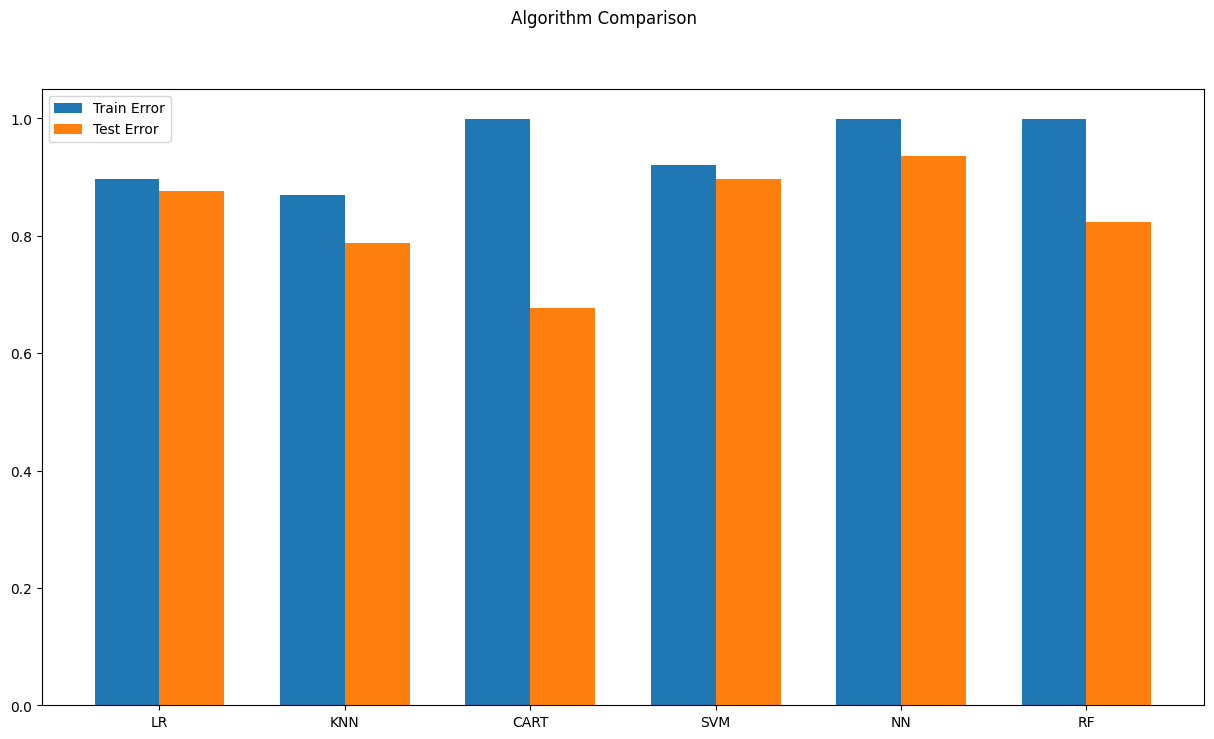

In [92]:
# compare algorithms
from matplotlib import pyplot
fig = pyplot.figure()
ind = np.arange(len(names))  # the x locations for the groups
width = 0.35  # the width of the bars
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

As we can see the NN model is the best performer with the a training accuracy of 99% and test accuracy of 93%. The performance of Random forest, SVM and Logistic regression are good as well. CART and KNN don't perform as good as other models. CART has higher overfitting as well.

## LSTM based model

In [93]:
### Create sequence
vocabulary_size = 20000
tokenizer = Tokenizer(num_words= vocabulary_size)
tokenizer.fit_on_texts(sentiments_data['headline'])
sequences = tokenizer.texts_to_sequences(sentiments_data['headline'])
X_LSTM = pad_sequences(sequences, maxlen=50)

In [94]:
Y_LSTM = sentiments_data["sentiment"]
X_train_LSTM, X_test_LSTM, Y_train_LSTM, Y_test_LSTM = train_test_split(X_LSTM, \
                       Y_LSTM, test_size=validation_size, random_state=seed)

In [96]:
# Define and train the Keras LSTM model directly
def create_model(input_length=50):
    model = Sequential()
    model.add(Embedding(20000, 300, input_length=50))
    model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Instantiate and fit the model directly
model_LSTM = create_model()
model_LSTM.fit(X_train_LSTM, Y_train_LSTM, epochs=3, batch_size=32, validation_split=0.4, verbose=1)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 293ms/step - accuracy: 0.8275 - loss: 0.3607 - val_accuracy: 0.9581 - val_loss: 0.1184
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.9832 - loss: 0.0568 - val_accuracy: 0.9679 - val_loss: 0.0803
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9957 - loss: 0.0177 - val_accuracy: 0.9774 - val_loss: 0.0668


In [98]:
# Convert probability outputs into binary class predictions
train_preds_LSTM = (model_LSTM.predict(X_train_LSTM) > 0.5).astype("int32")
train_result_LSTM = accuracy_score(train_preds_LSTM, Y_train_LSTM)

# Test results
test_preds_LSTM = (model_LSTM.predict(X_test_LSTM) > 0.5).astype("int32")
test_result_LSTM = accuracy_score(test_preds_LSTM, Y_test_LSTM)

print(f"LSTM Train Accuracy: {train_result_LSTM:.6f}")
print(f"LSTM Test Accuracy: {test_result_LSTM:.6f}")

208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
LSTM Train Accuracy: 0.990496
LSTM Test Accuracy: 0.971841


In [99]:
train_results.append(train_result_LSTM);test_results.append(test_result_LSTM)

In [100]:
names.append("LSTM")

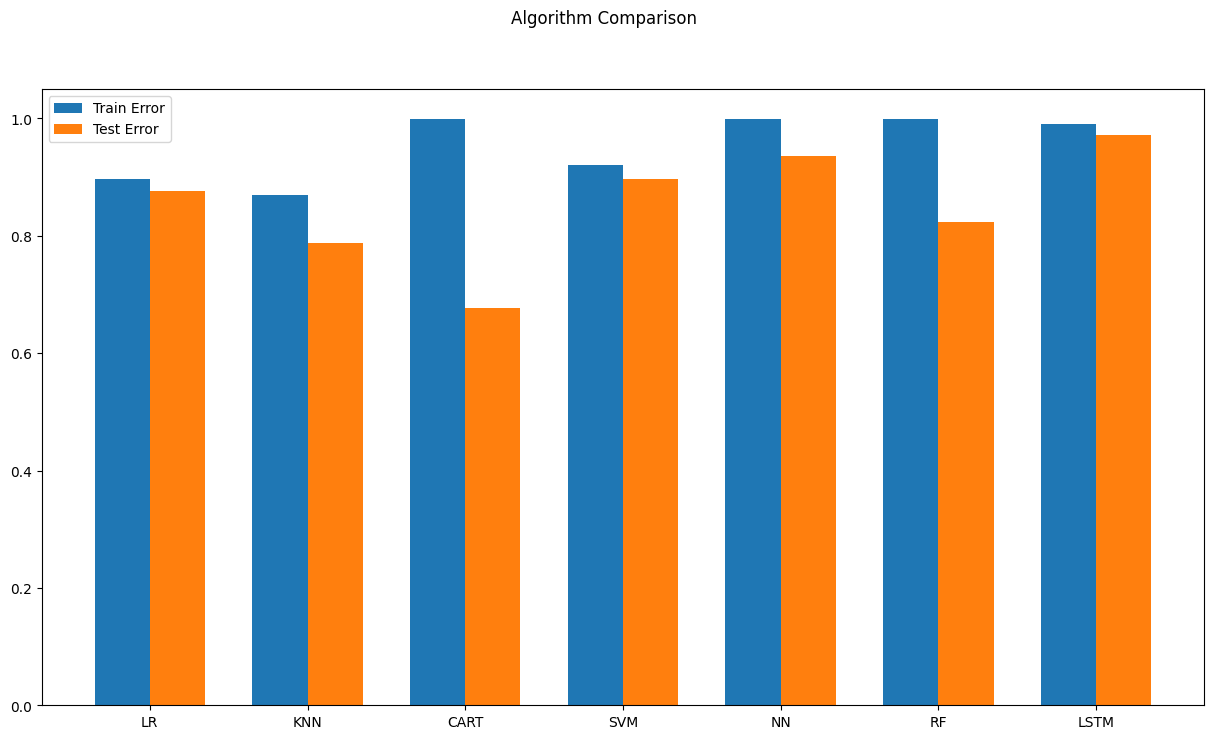

In [101]:
# compare algorithms
from matplotlib import pyplot
fig = pyplot.figure()
ind = np.arange(len(names))  # the x locations for the groups
width = 0.35  # the width of the bars
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

In [102]:
sequences_LSTM = tokenizer.texts_to_sequences(data_df['headline'])
X_LSTM = pad_sequences(sequences_LSTM, maxlen=50)

In [103]:
Y_LSTM = model_LSTM.predict(X_LSTM)

87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step


In [104]:
data_df['sentiment_LSTM'] = Y_LSTM

In [105]:
corrlation = data_df['eventRet'].corr(data_df['sentiment_LSTM'])
print(corrlation)

0.12922821784829727


In [106]:
data_df.head()

,ticker,headline,date,eventRet,Close,sentiment_textblob,sentiment_LSTM
5,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.017650,201.19,0.262500,0.014242
11,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,-0.013003,33.88,-0.043750,0.989999
74,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.019823,20.63,0.166667,0.912506
77,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.019823,20.63,-0.030556,0.995935
86,MSFT,,2011-05-10,-0.019823,20.63,0.000000,0.456759


## Unsupervised - Model based on financial lexicon

In [107]:
# stock market lexicon
sia = SentimentIntensityAnalyzer()
stock_lex = pd.read_csv('LexiconData.csv')
stock_lex['sentiment'] = (stock_lex['Aff_Score'] + stock_lex['Neg_Score'])/2
stock_lex = dict(zip(stock_lex.Item, stock_lex.sentiment))
stock_lex = {k:v for k,v in stock_lex.items() if len(k.split(' '))==1}
stock_lex_scaled = {}
for k, v in stock_lex.items():
    if v > 0:
        stock_lex_scaled[k] = v / max(stock_lex.values()) * 4
    else:
        stock_lex_scaled[k] = v / min(stock_lex.values()) * -4

final_lex = {}
final_lex.update(stock_lex_scaled)
final_lex.update(sia.lexicon)
sia.lexicon = final_lex

In [109]:
vader_sentiments = np.array([sia.polarity_scores(s)['compound'] for s in data_df['headline']])
vader_sentiments.shape

(2768,)

In [110]:
data_df['sentiment_lex'] = vader_sentiments
corrlation = data_df['eventRet'].corr(data_df['sentiment_lex'])
print(corrlation)

0.10443174163831649


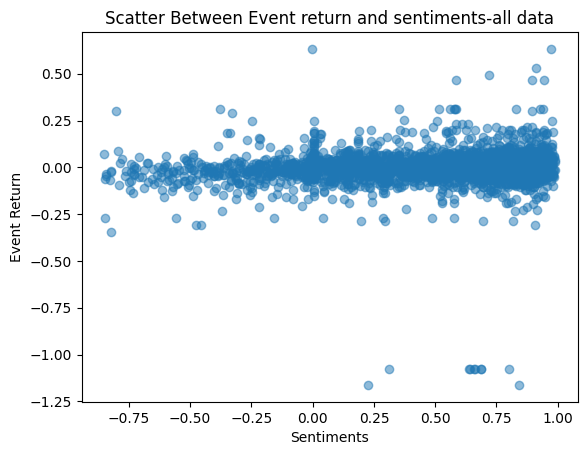

In [111]:
plt.scatter(data_df['sentiment_lex'],data_df['eventRet'], alpha=0.5)
plt.title('Scatter Between Event return and sentiments-all data')
plt.ylabel('Event Return')
plt.xlabel('Sentiments')
plt.show()

## Exploratory Data Analysis and comparison

In [112]:
data_new_df_stock=data_df[data_df['ticker']== 'NFLX'][['ticker','headline','sentiment_textblob','sentiment_LSTM','sentiment_lex']]
from pandas import option_context

with option_context('display.max_colwidth', 400):
    display(data_new_df_stock.head(1))

,ticker,headline,sentiment_textblob,sentiment_LSTM,sentiment_lex
11,NFLX,"Netflix (NFLX +1.1%) shares post early gains after Citigroup ups its rating to Buy and lifts its price target to $300 from $245. U.S. revenue growth is sustainable, Citi says, ""with a path to 50M subscribers by 2013,"" adding that NFLX has little competition in price, selection and convenience; mass market adoption of tablets will help, and the mass-market adoption phase is still to come.",-0.04375,0.989999,0.8575


<Axes: title={'center': 'Correlation Matrix'}>

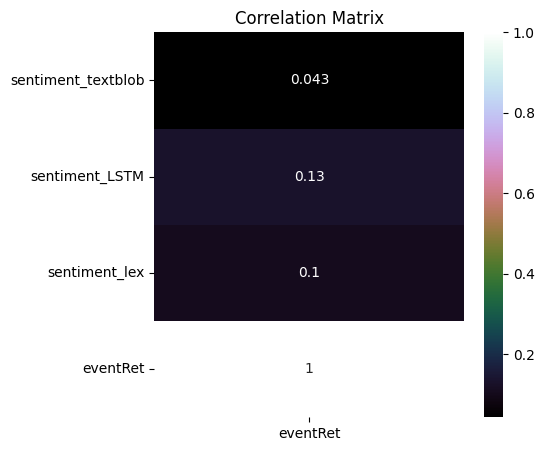

In [113]:
correlation = data_df[['sentiment_textblob','sentiment_LSTM','sentiment_lex','eventRet']].dropna(axis=0).corr()

plt.figure(figsize=(5,5))
plt.title('Correlation Matrix')
sns.heatmap(correlation[['eventRet']], vmax=1, annot=True,cmap='cubehelix')

In [114]:
corr_data = []
for ticker in data_df['ticker'].unique():
    data_new_df_stock=data_df[data_df['ticker']==ticker]
    #Only look for the stocks with sufficient data
    if data_new_df_stock.shape[0] > 40 :
        corr_textblob= data_new_df_stock['eventRet'].corr(data_new_df_stock['sentiment_textblob'])
        corr_LSTM = data_new_df_stock['eventRet'].corr(data_new_df_stock['sentiment_LSTM'])
        corr_lex = data_new_df_stock['eventRet'].corr(data_new_df_stock['sentiment_lex'])
        corr_data.append([ticker,corr_textblob, corr_LSTM, corr_lex])
        #print(ticker,corr_vader, corr_LSTM, corr_textblob)
    else:
        continue

In [115]:
corr_df = pd.DataFrame(corr_data, columns =  ['ticker','corr_textblob','corr_LSTM','corr_lex'])
corr_df=corr_df.set_index('ticker')
corr_df.head(1)

,corr_textblob,corr_LSTM,corr_lex
ticker,,,
AMZN,0.01983,0.179407,0.134881


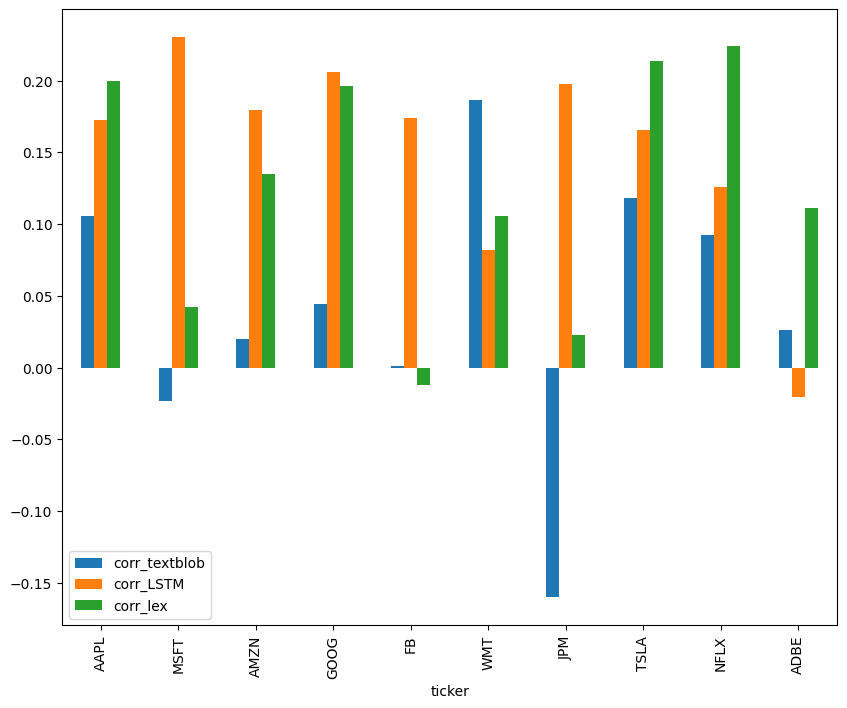

In [116]:
corr_df.loc[tickers].plot.bar(figsize = (10,8))
plt.show()

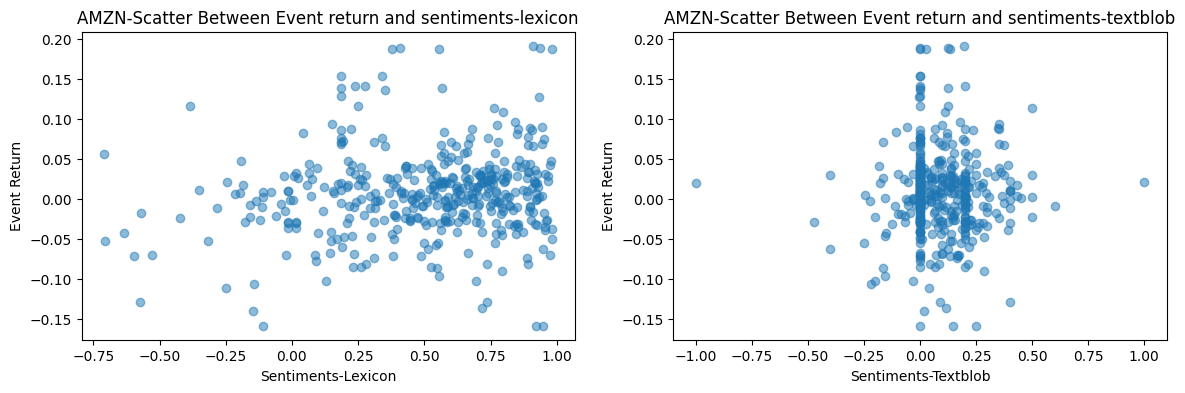

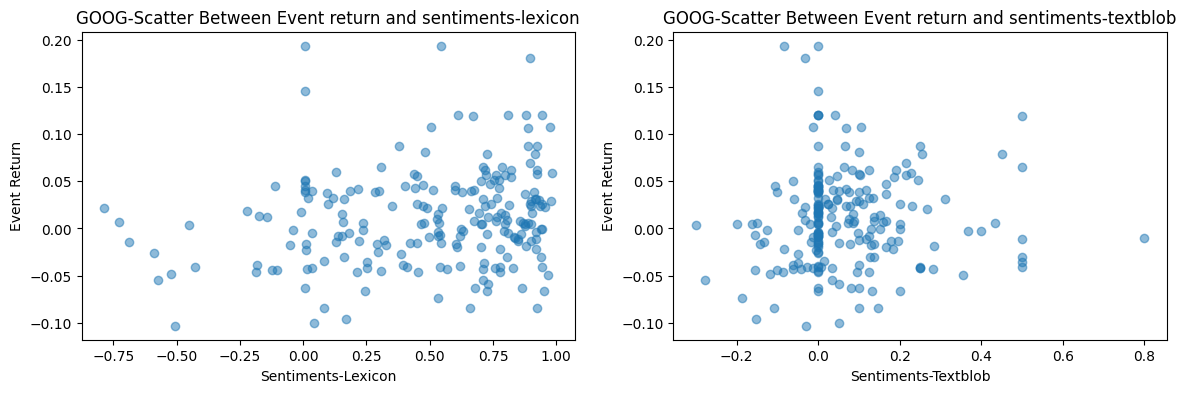

In [117]:
for ticker in tickers[2:4]:
    data_df_stock  = data_df[data_df['ticker'] == ticker]
    fig = plt.figure(figsize=(14, 4), constrained_layout=False)

    plt.subplot(1, 2, 1)
    plt.scatter(data_df_stock['sentiment_lex'],data_df_stock['eventRet'], alpha=0.5)
    plt.title(ticker + '-Scatter Between Event return and sentiments-lexicon')
    plt.ylabel('Event Return')
    plt.xlabel('Sentiments-Lexicon')


    plt.subplot(1, 2, 2)
    plt.scatter(data_df_stock['sentiment_textblob'],data_df_stock['eventRet'], alpha=0.5)
    plt.title(ticker + '-Scatter Between Event return and sentiments-textblob')
    plt.ylabel('Event Return')
    plt.xlabel('Sentiments-Textblob')
    plt.show()


## Model Evaluation- Building a Trading Strategy

The sentiment data can be used in different ways for the trading strategy. Sentiment scores can be used as a directional signal and ideally create a long-short portfolio, by buying the stocks with positive score and selling the stocks with negative score. The sentiments can also be used as additional features over and above other features(such as correlated stocks, technical indicators) in a supervised learning model to predict the price or come up with a trading strategy.

In the trading strategy in this case study we buy and sell stock as per the current stock sentiments :

* Buy a stock when the change in sentiment score (Current sentiment score - previous sentiment score) is greater than .5 and sell a stock when the change in sentiment score is less than -.5.
* Additionally, we check for 15 days moving average while buying and selling and buy or sell in a unit of 100.
Obviously, there can be many ways to create the trading strategy based in sentiments, by varying the threshold, or changing the number of units based on the initial cash available.

We use lexicon based sentiments for the trading strategy.

In [118]:
import backtrader as bt
import backtrader.indicators as btind
import backtrader.analyzers as btanalyzers

class Sentiment(bt.Indicator):
    lines = ('sentiment',)
    plotinfo = dict(
        plotymargin=0.5,
        plothlines=[0],
        plotyticks=[1.0, 0, -1.0])

    def next(self):
        self.sentiment = 0.0
        self.date = self.data.datetime
        date = bt.num2date(self.date[0]).date()
        prev_sentiment = self.sentiment
        if date in date_sentiment:
            self.sentiment = date_sentiment[date]
        self.lines.sentiment[0] = self.sentiment


class SentimentStrat(bt.Strategy):
    params = (
        ('period', 15),
        ('printlog', True),
    )

    def log(self, txt, dt=None, doprint=False):
        ''' Logging function for this strategy'''
        if self.params.printlog or doprint:
            dt = dt or self.datas[0].datetime.date(0)
            print('%s, %s' % (dt.isoformat(), txt))

    def __init__(self):
        # Keep a reference to the "close" line in the data[0] dataseries
        self.dataclose = self.datas[0].close
        # Keep track of pending orders
        self.order = None
        self.buyprice = None
        self.buycomm = None
        self.sma = bt.indicators.SimpleMovingAverage(
            self.datas[0], period=self.params.period)
        self.date = self.data.datetime
        self.sentiment = None
        Sentiment(self.data)
        self.plotinfo.plot = False


    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            # Buy/Sell order submitted/accepted to/by broker - Nothing to do
            return

        # Check if an order has been completed
        # Attention: broker could reject order if not enough cash
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(
                    'BUY EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                    (order.executed.price,
                     order.executed.value,
                     order.executed.comm))
                self.buyprice = order.executed.price
                self.buycomm = order.executed.comm
            else:  # Sell
                self.log('SELL EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                         (order.executed.price,
                          order.executed.value,
                          order.executed.comm))

            self.bar_executed = len(self)

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')

        # Write down: no pending order
        self.order = None

    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        self.log('OPERATION PROFIT, GROSS %.2f, NET %.2f' %
                 (trade.pnl, trade.pnlcomm))

    ### Main Strat ###
    def next(self):
        date = bt.num2date(self.date[0]).date()
        prev_sentiment = self.sentiment
        if date in date_sentiment:
            self.sentiment = date_sentiment[date]

        # Check if an order is pending. if yes, we cannot send a 2nd one
        if self.order:
            return
        # If not in the market and previous sentiment not none
        if not self.position and prev_sentiment:
            # buy if current close more than sma AND sentiment increased by >= 0.5
            if self.dataclose[0] > self.sma[0] and self.sentiment - prev_sentiment >= 0.5:
                self.log('Previous Sentiment %.2f, New Sentiment %.2f BUY CREATE, %.2f' % (prev_sentiment, self.sentiment, self.dataclose[0]))
                self.order = self.buy()

        # Already in the market and previous sentiment not none
        elif prev_sentiment:
            # sell if current close less than sma AND sentiment decreased by >= 0.5
            if self.dataclose[0] < self.sma[0] and self.sentiment - prev_sentiment <= -0.5:
                self.log('Previous Sentiment %.2f, New Sentiment %.2f SELL CREATE, %.2f' % (prev_sentiment, self.sentiment, self.dataclose[0]))
                self.order = self.sell()

    def stop(self):
        self.log('(MA Period %2d) Ending Value %.2f' %
                 (self.params.period, self.broker.getvalue()), doprint=True)

In [124]:
def run_strategy(ticker, start, end):
    print(ticker)
    ticker = yf.Ticker(ticker)
    df_ticker = ticker.history(start = start, end = end)

    cerebro = bt.Cerebro()
    # Add the data
    cerebro.addstrategy(SentimentStrat)
    data = bt.feeds.PandasData(dataname=df_ticker)
    cerebro.adddata(data)
    start = 100000.0
    cerebro.broker.setcash(start)
    cerebro.addsizer(bt.sizers.FixedSize, stake=100)
    print('Starting Portfolio Value: %.2f' % start)
    plt.rcParams['figure.figsize']=[10,6]
    plt.rcParams["font.size"]="12"
    cerebro.run()
    cerebro.plot(volume=False, iplot=True, plotname= ticker)
    end = cerebro.broker.getvalue()
    print('Start Portfolio value: %.2f\nFinal Portfolio Value: %.2f\nProfit: %.2f\n' \
          % (start, end, end - start))
    return float(df_ticker['Close'][0]), (end - start)

## Results for Individual Stocks

In [125]:
ticker = 'GOOG'
date_sentiment=data_df[data_df['ticker'].isin([ticker])]
date_sentiment=date_sentiment[['date','sentiment_lex']]
date_sentiment['date']=pd.to_datetime(date_sentiment['date'], format='%Y-%m-%d').dt.date
date_sentiment=date_sentiment.set_index('date')['sentiment_lex']
date_sentiment=date_sentiment.to_dict()

# Redefine run_strategy to use local preloaded return data and avoid TkAgg plotting error
def run_strategy_local(ticker_name, start_date, end_date, plot=False):
    print(ticker_name)
    # Filter pre-loaded df_ticker_return dataset for ticker and dates
    df_ticker = df_ticker_return[(df_ticker_return['ticker'] == ticker_name) &
                                 (df_ticker_return['Date'] >= start_date) &
                                 (df_ticker_return['Date'] <= end_date)].copy()

    # Prepare index for Backtrader
    df_ticker['Date'] = pd.to_datetime(df_ticker['Date'])
    df_ticker.set_index('Date', inplace=True)

    cerebro = bt.Cerebro()
    cerebro.addstrategy(SentimentStrat)
    data = bt.feeds.PandasData(dataname=df_ticker)
    cerebro.adddata(data)
    start_val = 100000.0
    cerebro.broker.setcash(start_val)
    cerebro.addsizer(bt.sizers.FixedSize, stake=100)
    print('Starting Portfolio Value: %.2f' % start_val)
    plt.rcParams['figure.figsize']=[10,6]
    plt.rcParams["font.size"]="12"
    cerebro.run()

    if plot:
        try:
            cerebro.plot(volume=False, iplot=False, plotname=ticker_name)
        except Exception as e:
            print(f"Could not plot automatically due to Backtrader Matplotlib backend conflict: {e}")

    end_val = cerebro.broker.getvalue()
    print('Start Portfolio value: %.2f\nFinal Portfolio Value: %.2f\nProfit: %.2f\n' \
          % (start_val, end_val, end_val - start_val))
    return float(df_ticker['Close'].iloc[0]), (end_val - start_val)

run_strategy_local(ticker, start_date = '2012-01-01', end_date = '2018-12-12', plot=False)

GOOG
Starting Portfolio Value: 100000.00
2012-04-12, Previous Sentiment 0.24, New Sentiment 0.80 BUY CREATE, 324.29
2012-04-13, BUY EXECUTED, Price: 322.57, Cost: 32257.00, Comm 0.00
2012-10-18, Previous Sentiment 0.98, New Sentiment 0.08 SELL CREATE, 346.20
2012-10-19, SELL EXECUTED, Price: 351.47, Cost: 32257.00, Comm 0.00
2012-10-19, OPERATION PROFIT, GROSS 2890.00, NET 2890.00
2013-01-10, Previous Sentiment 0.08, New Sentiment 0.80 BUY CREATE, 369.36
2013-01-11, BUY EXECUTED, Price: 369.61, Cost: 36961.00, Comm 0.00
2014-07-17, Previous Sentiment 0.73, New Sentiment -0.22 SELL CREATE, 572.16
2014-07-18, SELL EXECUTED, Price: 591.38, Cost: 36961.00, Comm 0.00
2014-07-18, OPERATION PROFIT, GROSS 22177.00, NET 22177.00
2014-07-18, Previous Sentiment -0.22, New Sentiment 0.77 BUY CREATE, 593.45
2014-07-21, BUY EXECUTED, Price: 590.13, Cost: 59013.00, Comm 0.00
2014-09-12, Previous Sentiment 0.66, New Sentiment -0.05 SELL CREATE, 574.04
2014-09-15, SELL EXECUTED, Price: 571.37, Cost: 59

(331.46, 49719.0)